# Importando as Bibliotecas

In [1]:
import pandas as pd
import re

print("Bibliotecas Salvas com Sucesso!!")

Bibliotecas Salvas com Sucesso!!


# Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


# 1. Pré-Processamento

## Limpando o Texto

In [3]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

In [4]:
def limpar_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)
    # 5. Expande contrações
    # Primeiro quebra o texto em palavras (texto.split())
    # Depois troca as contrações no dicionário (CONTRACTIONS)
    # Por fim junta tudo
    palavras = [CONTRACTIONS.get(p,p) for p in texto.split()]
    texto = ' '.join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [5]:
# Fazendo um teste da função
teste = "<p>ADOREI o produto!!! vc precisa comprar tbm https://loja.com</p>"
resultado = limpar_texto(teste)
print(resultado)

adorei o produto!!! você precisa comprar também


In [6]:
dados['texto_limpo'] = dados['review_comment_message'].apply(limpar_texto)
dados.head()

,review_comment_message,review_score,sentimento,texto_limpo
3,Recebi bem antes do prazo estipulado.,5,positivo,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,4,positivo,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo,"mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo,"vendedor confiável, produto ok e entrega antes..."


## Tokenização - Quebrando texto em unidades

In [7]:
import nltk
from nltk.corpus import stopwords

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.tokenize import word_tokenize

In [8]:
STOP_WORDS_PT = set(stopwords.words('portuguese'))

NEGACOES = {"não", "nao", "nunca", "nem", "sem"}

STOP_WORDS_PT = STOP_WORDS_PT - NEGACOES

In [9]:
modelo = "Eu sou cientista de dados"

tokens = word_tokenize(modelo, language="portuguese")
print(tokens)

['Eu', 'sou', 'cientista', 'de', 'dados']


In [10]:
def tokenizacao(texto):

    return word_tokenize(texto, language="portuguese")

In [11]:
dados["tokens"] = dados["texto_limpo"].apply(tokenizacao)

dados[["texto_limpo", "tokens"]].head()

,texto_limpo,tokens
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, do, prazo, estipulado, .]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, ., no, site, a, marca, d..."
12,"mas um pouco ,travando...pelo valor ta boa.","[mas, um, pouco, ,, travando, ..., pelo, valor..."
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, ,, produto, ok, e, entre..."


In [12]:
def remover_stop_words(tokens):
    resultado = []

    for token in tokens:
        if(
            token.isalpha() and token not in STOP_WORDS_PT
        ):
            resultado.append(token)
    return resultado

In [13]:
dados["tokens"] = dados["tokens"].apply(remover_stop_words)

dados[["texto_limpo", "tokens"]].head()

,texto_limpo,tokens
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, prazo, estipulado]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, site, marca, aparelho, i..."
12,"mas um pouco ,travando...pelo valor ta boa.","[pouco, travando, valor, ta, boa]"
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, produto, ok, entrega, an..."


## Stemming - Reduzindo palavras ao seu radical

In [14]:
from nltk.stem import RSLPStemmer
import nltk
nltk.download("rslp", quiet=True)

True

In [15]:
# exemplo
texto = ['correndo', 'correu', 'estudou', 'participou', 'ganhou']

stemmer_rslp = RSLPStemmer()
for palavras in texto:
    print(stemmer_rslp.stem(palavras))

corr
corr
estud
particip
ganh


In [16]:
def aplicar_stemming(tokens):
    resultado = []

    for token in tokens:
        resultado.append(stemmer_rslp.stem(token))

    return resultado

In [17]:
dados["stemmer"] = dados["tokens"].apply(aplicar_stemming)

dados[["texto_limpo", "tokens", "stemmer"]].head()

,texto_limpo,tokens,stemmer
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, prazo, estipulado]","[receb, bem, ant, praz, estipul]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabém, loj, lannist, ador, compr, internet,..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, site, marca, aparelho, i...","[aparelh, efici, sit, marc, aparelh, impress, ..."
12,"mas um pouco ,travando...pelo valor ta boa.","[pouco, travando, valor, ta, boa]","[pouc, trav, val, ta, boa]"
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, produto, ok, entrega, an...","[vend, confi, produt, ok, entreg, ant, praz]"


In [18]:
def juntar_palavras(textos):

    return " ".join(textos)

In [19]:
dados["dados_juntos"] = dados["stemmer"].apply(juntar_palavras)

dados[["stemmer", "dados_juntos"]].head()

,stemmer,dados_juntos
3,"[receb, bem, ant, praz, estipul]",receb bem ant praz estipul
4,"[parabém, loj, lannist, ador, compr, internet,...",parabém loj lannist ador compr internet segur ...
9,"[aparelh, efici, sit, marc, aparelh, impress, ...",aparelh efici sit marc aparelh impress desinfe...
12,"[pouc, trav, val, ta, boa]",pouc trav val ta boa
15,"[vend, confi, produt, ok, entreg, ant, praz]",vend confi produt ok entreg ant praz


## Pipeline Completo

In [41]:
def pipeline_tratamento(texto):
        
    texto = limpar_texto(texto)
    texto_tokenizado = tokenizacao(texto)
    texto_sem_stop_word = remover_stop_words(texto_tokenizado)
    texto_stemme = aplicar_stemming(texto_sem_stop_word)
    resultado = juntar_palavras(texto_stemme)

    return resultado

In [42]:
df_pipeline = dados[["review_comment_message", "sentimento"]].copy()
df_pipeline.head()

,review_comment_message,sentimento
3,Recebi bem antes do prazo estipulado.,positivo
4,Parabéns lojas lannister adorei comprar pela I...,positivo
9,aparelho eficiente. no site a marca do aparelh...,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",positivo
15,"Vendedor confiável, produto ok e entrega antes...",positivo


In [43]:
df_pipeline["review_tratado"] = df_pipeline["review_comment_message"].apply(pipeline_tratamento)
df_pipeline[["review_comment_message", "review_tratado"]].head()

,review_comment_message,review_tratado
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


# 2. Vetorizando Texto

## Divisão do Treinamento

In [20]:
from sklearn.model_selection import train_test_split

In [44]:
sentimento = {
    "positivo": 1,
    "negativo": 0
}
df_pipeline["sentimento"] = df_pipeline["sentimento"].map(sentimento)

print("Dados únicos do sentimento")
print(df_pipeline["sentimento"].unique())

Dados únicos do sentimento
[1 0]


In [46]:
X = df_pipeline["review_tratado"]
y = df_pipeline["sentimento"]

In [24]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

print(f"Dados Treino -> {len(X_treino)}")
print(f"Dados Teste -> {len(X_teste)}")

Dados Treino -> 26194
Dados Teste -> 11226


## TF-IDF

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    max_features=10000,
    sublinear_tf=True
)

In [49]:
X_tfidf = vectorizer.fit_transform(X_treino)
print(X_tfidf.shape)

(26194, 5755)


In [50]:
feature_names = vectorizer.get_feature_names_out()

print(f"Quantidade de features: {len(feature_names)}")
print(feature_names[:50])

Quantidade de features: 5755
['ab' 'abaix' 'abajur' 'abenço' 'abert' 'aborrec' 'abr' 'abr caix'
 'abr embal' 'abr produt' 'abr reclam' 'abraç' 'abril' 'absurd' 'acab'
 'acab bem' 'acab boa' 'acab bom' 'acab cheg' 'acab compr' 'acab entreg'
 'acab não' 'acab perfeit' 'acab produt' 'acab receb' 'acab recom'
 'acab ruim' 'aceit' 'acend' 'acert' 'acess' 'acessóri' 'ach' 'ach absurd'
 'ach bem' 'ach bom' 'ach car' 'ach demor' 'ach dev' 'ach entreg'
 'ach falt' 'ach fret' 'ach loj' 'ach mater' 'ach melhor' 'ach não'
 'ach pequen' 'ach pod' 'ach pouc' 'ach produt']


In [51]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

doc = X_tfidf[0].toarray().flatten()

top_idx = np.argsort(doc)[-10:][::-1]

for i in top_idx:
    if doc[i] > 0:
        print(f"{feature_names[i]:20} {doc[i]:.3f}")

med não              0.336
fiq med              0.331
compr fiq            0.320
ia                   0.300
env                  0.295
devolv dinh          0.285
faz compr            0.280
med                  0.245
dinh                 0.210
devolv               0.210


# 3. Modelos de NLP

In [56]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Modelo Naive Bayes

In [53]:
pipeline_nb = Pipeline([
    ('tfidf', vectorizer),
    ('modelo_nb', MultinomialNB(alpha=1.0))
])

In [54]:
pipeline_nb.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('modelo_nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True


In [55]:
previsao_nb = pipeline_nb.predict(X_teste)

print("=== Resultados Modelo Naive Bayes ===")
print(classification_report(y_teste, previsao_nb))

=== Resultados Modelo Naive Bayes ===
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      3267
           1       0.96      0.94      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.92      0.92     11226
weighted avg       0.93      0.93      0.93     11226



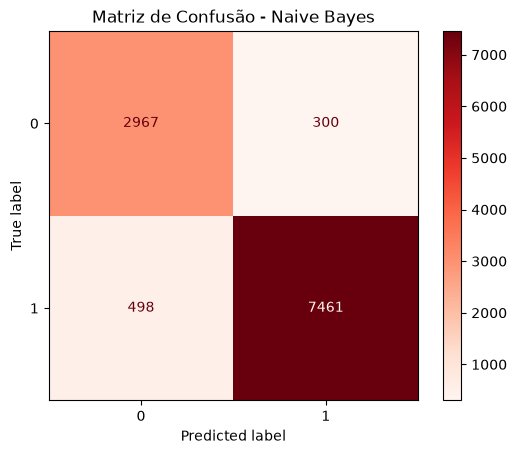

In [58]:
ConfusionMatrixDisplay.from_estimator(pipeline_nb, X_teste, y_teste, cmap="Reds")
plt.title("Matriz de Confusão - Naive Bayes")
plt.show()

## Modelo Regressão Logística

In [59]:
pipeline_rl = Pipeline([
    ("tfidf", vectorizer),
    ("modelo_rl", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

In [60]:
pipeline_rl.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('modelo_rl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True


In [61]:
previsao_rl = pipeline_rl.predict(X_teste)

print("=== Resultados Modelo Regressão Logística ===")
print(classification_report(y_teste, previsao_rl))

=== Resultados Modelo Regressão Logística ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.94      0.93      0.93     11226



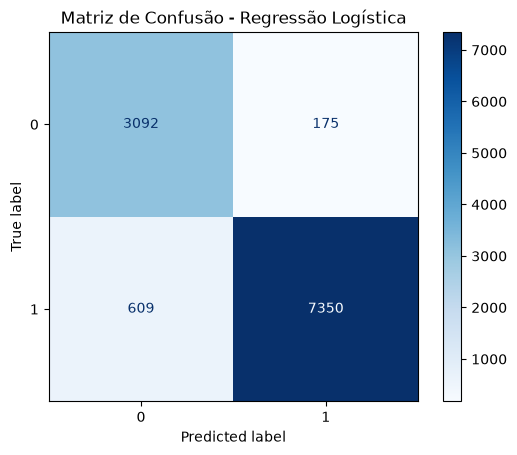

In [62]:
ConfusionMatrixDisplay.from_estimator(pipeline_rl, X_teste, y_teste, cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

## Modelo SVM - Support Vector Machine

In [64]:
pipeline_svm = Pipeline([
    ("tfidf", vectorizer),
    ("modelo_svm", LinearSVC(class_weight="balanced", random_state=42))
])

In [65]:
pipeline_svm.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('modelo_svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True


In [66]:
previsao_svm = pipeline_svm.predict(X_teste)

print("=== Resultados Modelo SVM ===")
print(classification_report(y_teste, previsao_svm))

=== Resultados Modelo SVM ===
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226



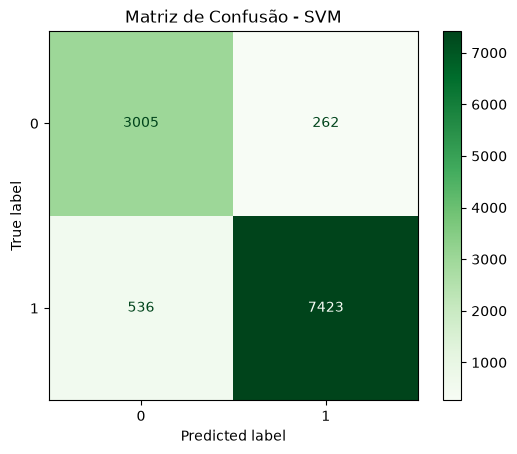

In [67]:
ConfusionMatrixDisplay.from_estimator(pipeline_svm, X_teste, y_teste, cmap="Greens")
plt.title("Matriz de Confusão - SVM")
plt.show()